# Multi-Objective Mountain Car (`mo-mountaincar-v0`)
## Exploración con PCN y GPI-LS

**Curso:** Aprendizaje por Refuerzo — Maestría en Ingeniería
**Ambiente:** MO-MountainCar — MO-Gymnasium
**Algoritmos:** PCN (Pareto Conditioned Network) · GPI-LS (GPI-PD neuronal)

---

## 1. Introducción al Problema

Mountain Car es el primer ambiente de **estado continuo** en esta serie. La clave:

> El coche **no puede** escalar la colina directamente — debe oscilar izquierda-derecha para acumular energía cinética. Cada oscilación cuesta penalización en $r_L$ o $r_R$.

El estado continuo hace inviables los métodos tabulares (PQL, Q-Learning escalarizado con tabla). Necesitamos **aproximación de función neuronal**.

| Algoritmo | Condicionamiento | ¿Discretización? |
|---|---|---|
| **PQL** | — | Sí (falla aquí) |
| **PCN** | Retorno objetivo $\mathbf{d} \in \mathbb{R}^3$ | No |
| **GPI-LS** | Pesos $\mathbf{w} \in \Delta^2$ | No |

In [1]:
!pip install mo-gymnasium morl-baselines imageio --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics
import os, warnings, imageio
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

os.makedirs('videos', exist_ok=True)
os.makedirs('resources/env_gifs', exist_ok=True)
os.makedirs('resources/agent_gifs', exist_ok=True)
os.makedirs('resources/agent_videos', exist_ok=True)

ENV_ID = 'mo-mountaincar-v0'
GAMMA  = 1.0
print('Dependencias cargadas correctamente')

Dependencias cargadas correctamente


/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 2. El Ambiente: Mountain Car Multiobjetivo

### Especificación

| Componente | Detalle |
|---|---|
| **Estado** $s \in \mathbb{R}^2$ | $[x,\, \dot{x}]$ — posición $x \in [-1.2,\, 0.6]$, velocidad $\dot{x} \in [-0.07,\, 0.07]$ |
| **Acciones** | 3 — empujar izquierda (0), ninguna (1), empujar derecha (2) |
| **Recompensa** $\mathbf{r} \in \mathbb{R}^3$ | $\mathbf{r} = [r_t,\, r_L,\, r_R]$ — todos negativos o cero |

$$\mathbf{r} = \begin{cases} r_t = -1 & \text{en cada paso de tiempo} \\ r_L = -1 & \text{si acción} = \text{izquierda},\; 0 \text{ si no} \\ r_R = -1 & \text{si acción} = \text{derecha},\; 0 \text{ si no} \end{cases}$$

### Trade-off fundamental

Para ganar impulso el agente **debe** acelerar (izq. y der.), acumulando penalizaciones $r_L$ y $r_R$.
Los tres objetivos están en conflicto:

- Minimizar tiempo → acabar rápido → muchas aceleraciones → $r_L, r_R$ muy negativos
- Minimizar aceleraciones → pocas acciones → movimiento lento → $r_t$ muy negativo

### ¿Por qué fallan los métodos tabulares?

$|\mathcal{S}|$ es infinito ($\mathcal{S} \subset \mathbb{R}^2$). Una tabla Q requeriría infinitas entradas.
Se necesita **aproximación de función**: red neuronal $Q(s, a; \theta)$.

In [3]:
env = mo_gym.make(ENV_ID)
print('=' * 55)
print('   MOUNTAIN CAR — INFORMACIÓN DEL AMBIENTE')
print('=' * 55)
print(f'\n  Espacio de estados  : {env.observation_space}')
print(f'  Espacio de acciones : {env.action_space}')
try:
    print(f'  Espacio de recomp.  : {env.unwrapped.reward_space}')
except Exception:
    pass

print('\n--- Ejemplo de interacción (política aleatoria) ---')
obs, _ = env.reset()
print(f'  Estado inicial: {obs}')
action_names = ['Izquierda', 'Ninguna', 'Derecha']
for step in range(6):
    action = env.action_space.sample()
    next_obs, r_vec, terminated, truncated, _ = env.step(action)
    print(f'  Paso {step+1}: {action_names[action]:>10} | x={next_obs[0]:+.4f} v={next_obs[1]:+.5f} | r={r_vec}')
    if terminated or truncated:
        print('           -> Episodio terminado')
        break
env.close()

   MOUNTAIN CAR — INFORMACIÓN DEL AMBIENTE

  Espacio de estados  : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Espacio de acciones : Discrete(3)
  Espacio de recomp.  : Box(-1.0, [-1.  0.  0.], (3,), float32)

--- Ejemplo de interacción (política aleatoria) ---
  Estado inicial: [-0.5812664  0.       ]
  Paso 1:  Izquierda | x=-0.5818 v=-0.00057 | r=[-1. -1.  0.]
  Paso 2:  Izquierda | x=-0.5830 v=-0.00114 | r=[-1. -1.  0.]
  Paso 3:    Derecha | x=-0.5827 v=+0.00031 | r=[-1.  0. -1.]
  Paso 4:  Izquierda | x=-0.5829 v=-0.00025 | r=[-1. -1.  0.]
  Paso 5:  Izquierda | x=-0.5837 v=-0.00081 | r=[-1. -1.  0.]
  Paso 6:  Izquierda | x=-0.5851 v=-0.00136 | r=[-1. -1.  0.]


## 3. Visualización del Ambiente

In [4]:
def record_episode(env_id, policy_fn, filepath, fps=15, max_steps=200):
    """Graba un episodio y retorna (frames, retorno_acumulado)."""
    env = mo_gym.make(env_id, render_mode='rgb_array')
    obs, _ = env.reset()
    frames = []
    r_cumul = np.zeros(3)
    done = False
    step = 0
    while not done and step < max_steps:
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        action = policy_fn(obs)
        obs, rew, term, trunc, _ = env.step(action)
        r_cumul += rew
        done = term or trunc
        step += 1
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    env.close()
    if frames:
        writer = imageio.get_writer(filepath + '.mp4', fps=fps)
        for f in frames:
            writer.append_data(f)
        writer.close()
        print(f'  Video guardado: {filepath}.mp4  ({step} pasos, r={np.round(r_cumul, 1)})')
    return frames, r_cumul


def show_video(filepath, width=420):
    display(HTML(
        f'<video width="{width}" controls loop autoplay muted>'
        f'<source src="{filepath}.mp4" type="video/mp4"></video>'
    ))


print('Grabando episodio con política aleatoria...')
frames_rnd, _ = record_episode(
    ENV_ID, lambda obs: np.random.randint(3), 'videos/mc_random', fps=15
)
if frames_rnd:
    imageio.mimsave('resources/env_gifs/mountaincar_random.gif', frames_rnd, fps=15, loop=0)
    print('GIF guardado: resources/env_gifs/mountaincar_random.gif')
show_video('videos/mc_random')

Grabando episodio con política aleatoria...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/mc_random.mp4  (200 pasos, r=[-200.  -61.  -74.])


GIF guardado: resources/env_gifs/mountaincar_random.gif


## 4. Espacio de Objetivos en $\mathbb{R}^3$

Mountain Car **no** tiene `pareto_front()` porque el frente óptimo depende del algoritmo entrenado.
Estimamos el **espacio de objetivos alcanzable** con 150 episodios de política aleatoria.

Cada punto es el retorno acumulado $(r_t, r_L, r_R)$ de un episodio. El frente de Pareto estaría en la región con penalizaciones totales menores (más cerca del origen).

> Nota: como todos los objetivos son penalizaciones (negativos), **más cerca del origen = mejor**.

Estimando espacio de objetivos (150 episodios aleatorios)...
Resultados (150 episodios aleatorios):
  Tiempo ($r_t$)        : media=-200.0, rango=[-200, -200]
  Accel. Izq. ($r_L$)   : media=-66.3, rango=[-87, -51]
  Accel. Der. ($r_R$)   : media=-66.9, rango=[-93, -54]


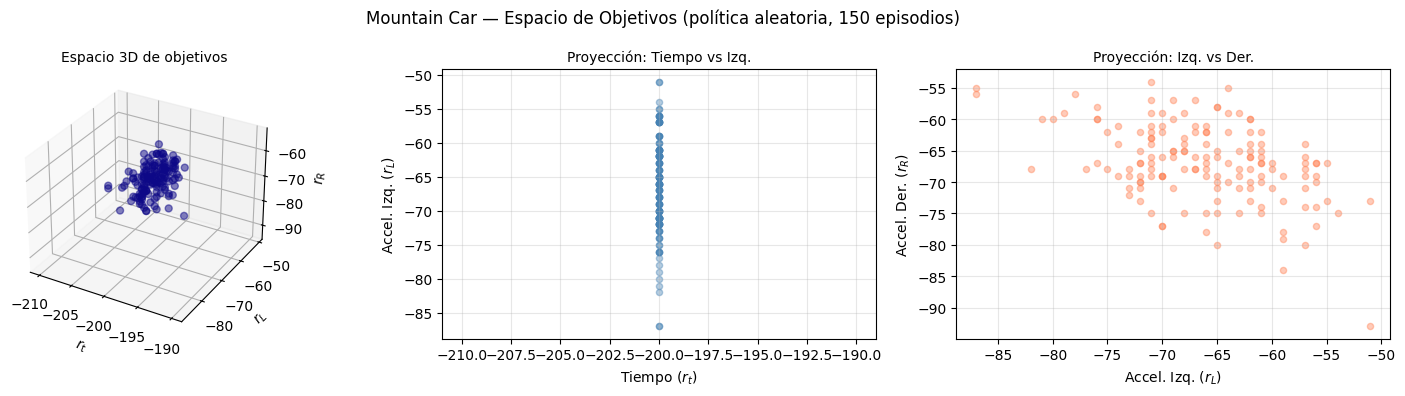

In [5]:
print('Estimando espacio de objetivos (150 episodios aleatorios)...')
env_samp = mo_gym.make(ENV_ID)
samples = []
for _ in range(150):
    obs_s, _ = env_samp.reset()
    r_t = r_l = r_r = 0.0
    done_s = False
    while not done_s:
        a_s = env_samp.action_space.sample()
        obs_s, rew_s, term_s, trunc_s, _ = env_samp.step(a_s)
        r_t += rew_s[0]; r_l += rew_s[1]; r_r += rew_s[2]
        done_s = term_s or trunc_s
    samples.append([r_t, r_l, r_r])
env_samp.close()
samples = np.array(samples)

print(f'Resultados (150 episodios aleatorios):')
for name, col in [('Tiempo ($r_t$)', 0), ('Accel. Izq. ($r_L$)', 1), ('Accel. Der. ($r_R$)', 2)]:
    print(f'  {name:<22}: media={samples[:,col].mean():.1f}, '
          f'rango=[{samples[:,col].min():.0f}, {samples[:,col].max():.0f}]')

fig = plt.figure(figsize=(15, 4))

ax3 = fig.add_subplot(131, projection='3d')
ax3.scatter(samples[:,0], samples[:,1], samples[:,2],
            c=samples[:,0], cmap='plasma', alpha=0.5, s=25)
ax3.set_xlabel('$r_t$'); ax3.set_ylabel('$r_L$'); ax3.set_zlabel('$r_R$')
ax3.set_title('Espacio 3D de objetivos', fontsize=10)

ax1 = fig.add_subplot(132)
ax1.scatter(samples[:,0], samples[:,1], alpha=0.4, s=20, c='steelblue')
ax1.set_xlabel('Tiempo ($r_t$)'); ax1.set_ylabel('Accel. Izq. ($r_L$)')
ax1.set_title('Proyección: Tiempo vs Izq.', fontsize=10); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(133)
ax2.scatter(samples[:,1], samples[:,2], alpha=0.4, s=20, c='coral')
ax2.set_xlabel('Accel. Izq. ($r_L$)'); ax2.set_ylabel('Accel. Der. ($r_R$)')
ax2.set_title('Proyección: Izq. vs Der.', fontsize=10); ax2.grid(alpha=0.3)

plt.suptitle('Mountain Car — Espacio de Objetivos (política aleatoria, 150 episodios)', fontsize=12)
plt.tight_layout()
plt.savefig('videos/mc_objective_space.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Intento con PQL — Por Qué Falla

Pareto Q-Learning (PQL) es un método tabular: requiere convertir el estado en un índice entero mediante `np.ravel_multi_index`. Con estados continuos en $\mathbb{R}^2$, esto es imposible.

In [6]:
from morl_baselines.multi_policy.pareto_q_learning.pql import PQL

env_pql = mo_gym.make(ENV_ID)
env_pql = MORecordEpisodeStatistics(env_pql, gamma=GAMMA)
eval_env_pql = mo_gym.make(ENV_ID)

try:
    agent_pql = PQL(
        env=env_pql,
        ref_point=np.array([-200.0, -200.0, -200.0]),
        gamma=GAMMA,
        log=False,
    )
    agent_pql.train(
        total_timesteps=5000,
        eval_env=eval_env_pql,
        ref_point=np.array([-200.0, -200.0, -200.0]),
    )
except Exception as e:
    print(f'PQL falló como se esperaba:')
    print(f'  {e}')
    print()
    print('-> Estado continuo en R² no puede indexarse con ravel_multi_index.')
    print('-> Solución: métodos neuronales (PCN, GPI-LS).')
finally:
    env_pql.close()
    eval_env_pql.close()

PQL falló como se esperaba:
  PQL only supports discretizable observation spaces.

-> Estado continuo en R² no puede indexarse con ravel_multi_index.
-> Solución: métodos neuronales (PCN, GPI-LS).


## 6. Algoritmo 1: PCN (Pareto Conditioned Network)

### Idea

PCN (Reymond et al., 2022) entrena una red neuronal $\pi_\theta(s, \mathbf{d})$ condicionada en el **retorno objetivo deseado** $\mathbf{d} \in \mathbb{R}^3$:

$$\pi_\text{PCN}(s, \mathbf{d}) = \arg\max_a Q_\theta(s, a \mid \mathbf{d})$$

La red aprende a producir comportamientos que se aproximen al retorno deseado. Al cambiar $\mathbf{d}$, se obtienen distintas políticas del frente de Pareto — **todo con una sola red**.

### Parámetros clave

| Parámetro | Descripción |
|---|---|
| `scaling_factor` $[s_1, s_2, s_3, s_h]$ | Escala de cada objetivo + horizonte temporal |
| `ref_point` | Peor retorno posible (cota inferior del frente) |
| `max_return` | Mejor retorno posible (cota superior) |
| `max_buffer_size` | Tamaño máximo del buffer de experiencias |

In [7]:
from morl_baselines.multi_policy.pcn.pcn import PCN

REF_POINT  = np.array([-200.0, -200.0, -200.0])
MAX_RETURN = np.array([0.0, 0.0, 0.0])
PCN_STEPS  = 10000

print('Configurando PCN...')
print(f'  ref_point  = {REF_POINT}')
print(f'  max_return = {MAX_RETURN}')
print(f'  timesteps  = {PCN_STEPS:,}  (demo — convergencia completa ~500k)')

env_pcn = mo_gym.make(ENV_ID)
env_pcn = MORecordEpisodeStatistics(env_pcn, gamma=GAMMA)
eval_env_pcn = mo_gym.make(ENV_ID)

agent_pcn = PCN(
    env_pcn,
    scaling_factor=np.array([1.0, 1.0, 1.0, 0.1]),
    log=False,
)

print('\nEntrenando PCN...')
agent_pcn.train(
    PCN_STEPS,
    eval_env=eval_env_pcn,
    ref_point=REF_POINT,
    max_return=MAX_RETURN,
    max_buffer_size=200,
)
print('Entrenamiento PCN completado.')
env_pcn.close()
eval_env_pcn.close()

Configurando PCN...
  ref_point  = [-200. -200. -200.]
  max_return = [0. 0. 0.]
  timesteps  = 10,000  (demo — convergencia completa ~500k)



Entrenando PCN...


step 6000 	 return [-200.   -61.9  -71.6], ([0.       5.3      3.720215]) 	 loss 1.096E+00 	 horizons 200.0


step 8000 	 return [-200.   -62.4  -64.2], ([0.        4.2941823 3.3105893]) 	 loss 1.088E+00 	 horizons 200.0


step 10000 	 return [-200.   -55.7  -64.4], ([0.        2.7946377 3.231099 ]) 	 loss 1.087E+00 	 horizons 200.0


Entrenamiento PCN completado.


### Evaluación PCN — Distintas Preferencias

Evaluamos la política PCN con diferentes retornos objetivo $\mathbf{d}$, representando distintas preferencias sobre los 3 objetivos.

Evaluando PCN (5 episodios por configuración):
  Retorno objetivo                           r_t     r_L     r_R
  --------------------------------------------------------------
  Prioriza tiempo (rápido)                -200.0   -61.6   -72.2
  Balance                                 -200.0   -65.0   -68.2
  Tiempo medio                            -200.0   -63.8   -71.4


  Evitar aceleraciones                    -200.0   -68.4   -65.0


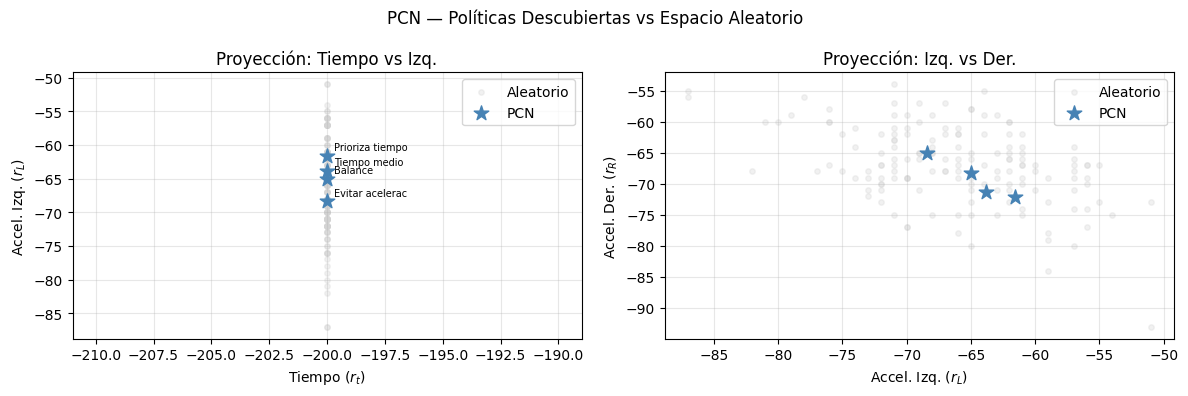

In [8]:
PCN_EVAL_CONFIGS = [
    (np.array([-20.0,  -5.0,  -5.0]), 'Prioriza tiempo (rápido)'),
    (np.array([-50.0, -50.0, -50.0]), 'Balance'),
    (np.array([-100.0, -20.0, -20.0]), 'Tiempo medio'),
    (np.array([-80.0, -60.0, -60.0]), 'Evitar aceleraciones'),
]

print('Evaluando PCN (5 episodios por configuración):')
print(f'  {"Retorno objetivo":<38} {"r_t":>7} {"r_L":>7} {"r_R":>7}')
print('  ' + '-' * 62)

pcn_pts = []
for desired_return, label in PCN_EVAL_CONFIGS:
    returns = []
    env_ev = mo_gym.make(ENV_ID)
    for _ in range(5):
        obs_ev, _ = env_ev.reset()
        r_cumul = np.zeros(3)
        done_ev = False
        step_ev = 0
        while not done_ev and step_ev < 200:
            try:
                action_ev = agent_pcn.eval(obs_ev, desired_return)
            except Exception:
                action_ev = env_ev.action_space.sample()
            obs_ev, rew_ev, term_ev, trunc_ev, _ = env_ev.step(action_ev)
            r_cumul += rew_ev
            done_ev = term_ev or trunc_ev
            step_ev += 1
        returns.append(r_cumul)
    env_ev.close()
    mean_r = np.mean(returns, axis=0)
    pcn_pts.append(mean_r)
    print(f'  {label:<38} {mean_r[0]:>7.1f} {mean_r[1]:>7.1f} {mean_r[2]:>7.1f}')

pcn_pts = np.array(pcn_pts)

# Visualizar sobre el espacio de objetivos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(samples[:,0], samples[:,1], c='lightgray', alpha=0.3, s=15, label='Aleatorio')
axes[0].scatter(pcn_pts[:,0], pcn_pts[:,1], c='steelblue', s=120, marker='*', zorder=5, label='PCN')
for i, (_, lbl) in enumerate(PCN_EVAL_CONFIGS):
    axes[0].annotate(lbl[:15], pcn_pts[i,:2], fontsize=7,
                     xytext=(5, 4), textcoords='offset points')
axes[0].set_xlabel('Tiempo ($r_t$)'); axes[0].set_ylabel('Accel. Izq. ($r_L$)')
axes[0].set_title('Proyección: Tiempo vs Izq.'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(samples[:,1], samples[:,2], c='lightgray', alpha=0.3, s=15, label='Aleatorio')
axes[1].scatter(pcn_pts[:,1], pcn_pts[:,2], c='steelblue', s=120, marker='*', zorder=5, label='PCN')
axes[1].set_xlabel('Accel. Izq. ($r_L$)'); axes[1].set_ylabel('Accel. Der. ($r_R$)')
axes[1].set_title('Proyección: Izq. vs Der.'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('PCN — Políticas Descubiertas vs Espacio Aleatorio', fontsize=12)
plt.tight_layout()
plt.savefig('videos/mc_pcn_eval.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
print('Grabando video del agente PCN...')

def pcn_policy(obs, desired_return=np.array([-50.0, -50.0, -50.0])):
    try:
        return agent_pcn.eval(obs, desired_return)
    except Exception:
        return np.random.randint(3)

frames_pcn, r_pcn = record_episode(ENV_ID, pcn_policy, 'videos/mc_pcn_demo', fps=15)
if frames_pcn:
    imageio.mimsave('resources/agent_gifs/mountaincar_pcn.gif', frames_pcn, fps=15, loop=0)
    print('GIF guardado: resources/agent_gifs/mountaincar_pcn.gif')
    writer = imageio.get_writer('resources/agent_videos/mountaincar_best.mp4', fps=15)
    for f in frames_pcn:
        writer.append_data(f)
    writer.close()
    print('MP4 guardado: resources/agent_videos/mountaincar_best.mp4')

show_video('videos/mc_pcn_demo')

Grabando video del agente PCN...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/mc_pcn_demo.mp4  (200 pasos, r=[-200.  -71.  -62.])


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


GIF guardado: resources/agent_gifs/mountaincar_pcn.gif


MP4 guardado: resources/agent_videos/mountaincar_best.mp4


## 7. Análisis de Parámetros — PCN

### `scaling_factor`

El `scaling_factor = [s_1, s_2, s_3, s_h]` normaliza los objetivos y el horizonte dentro de la red de condicionamiento.

- $s_i$ grande → el objetivo $i$ tiene más peso en el aprendizaje de la red
- $s_h$ (horizonte): controla cuánto importa el número de pasos restantes en el episodio
- Valores desequilibrados pueden hacer que la red ignore ciertos objetivos

### `ref_point`

El punto de referencia define el **peor retorno admisible**. Debe estar estrictamente por debajo de todos los puntos del frente de Pareto. Un `ref_point` demasiado cercano al frente reduce la señal de aprendizaje.

Comparando scaling_factor (3000 pasos cada uno)...
  Igual [1,1,1,0.1]                      r=[-200, -72, -67]  (~200 pasos/ep)


  Énfasis tiempo [2,0.5,0.5,0.1]         r=[-200, -71, -65]  (~200 pasos/ep)
  Énfasis accel [0.5,2,2,0.1]            r=[-200, -69, -67]  (~200 pasos/ep)


  Horizonte alto [1,1,1,0.5]             r=[-200, -67, -67]  (~200 pasos/ep)


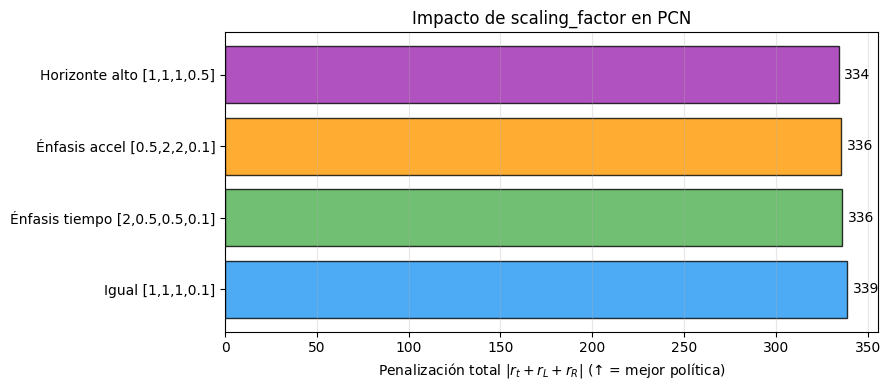

In [10]:
SCALING_TESTS = [
    (np.array([1.0, 1.0, 1.0, 0.1]), 'Igual [1,1,1,0.1]'),
    (np.array([2.0, 0.5, 0.5, 0.1]), 'Énfasis tiempo [2,0.5,0.5,0.1]'),
    (np.array([0.5, 2.0, 2.0, 0.1]), 'Énfasis accel [0.5,2,2,0.1]'),
    (np.array([1.0, 1.0, 1.0, 0.5]), 'Horizonte alto [1,1,1,0.5]'),
]

scaling_results = {}
print('Comparando scaling_factor (3000 pasos cada uno)...')
for sf, label in SCALING_TESTS:
    env_sf = mo_gym.make(ENV_ID)
    env_sf = MORecordEpisodeStatistics(env_sf, gamma=GAMMA)
    ev_sf  = mo_gym.make(ENV_ID)
    ag_sf  = PCN(env_sf, scaling_factor=sf, log=False)
    ag_sf.train(3000, eval_env=ev_sf, ref_point=REF_POINT,
                max_return=MAX_RETURN, max_buffer_size=200)
    env_sf.close(); ev_sf.close()

    env_ev2 = mo_gym.make(ENV_ID)
    pts = []
    d_test = np.array([-50.0, -50.0, -50.0])
    for _ in range(5):
        obs_sf, _ = env_ev2.reset()
        r_sf = np.zeros(3); done_sf = False; step_sf = 0
        while not done_sf and step_sf < 200:
            try:
                a_sf = ag_sf.eval(obs_sf, d_test)
            except Exception:
                a_sf = env_ev2.action_space.sample()
            obs_sf, rew_sf, term_sf, trunc_sf, _ = env_ev2.step(a_sf)
            r_sf += rew_sf; done_sf = term_sf or trunc_sf; step_sf += 1
        pts.append(r_sf)
    env_ev2.close()
    mean_pt = np.mean(pts, axis=0)
    scaling_results[label] = (mean_pt, step_sf)
    print(f'  {label:<38} r=[{mean_pt[0]:.0f}, {mean_pt[1]:.0f}, {mean_pt[2]:.0f}]  (~{step_sf} pasos/ep)')

fig, ax = plt.subplots(figsize=(9, 4))
labels_sf = list(scaling_results.keys())
totals = [-(v[0].sum()) for v in scaling_results.values()]  # total penalty (lower = worse)
colors_sf = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.barh(labels_sf, totals, color=colors_sf, edgecolor='black', alpha=0.8)
ax.set_xlabel('Penalización total $|r_t + r_L + r_R|$ (↑ = mejor política)')
ax.set_title('Impacto de scaling_factor en PCN', fontsize=12)
ax.bar_label(bars, fmt='%.0f', padding=4)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('videos/mc_scaling_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Algoritmo 2: GPI-LS Neuronal (GPI-PD)

### Generalised Policy Improvement con Linear Support

GPI-LS neuronal (Alegre et al., 2023) adapta el algoritmo tabular GPI-LS a espacios continuos usando una **red Q neuronal**. La política GPI selecciona la acción que maximiza el producto interno con el vector de pesos $\mathbf{w}$ sobre todas las políticas aprendidas:

$$\text{GPI}(s, \mathbf{w}) = \arg\max_a \max_{\pi \in \Pi} \mathbf{w}^\top \mathbf{Q}^\pi(s, a)$$

**Linear Support** selecciona automáticamente los pesos $\mathbf{w}$ que maximizan el hipervolumen del frente descubierto.

### Comparación con PCN

| Aspecto | PCN | GPI-LS |
|---|---|---|
| Condicionamiento | Retorno objetivo $\mathbf{d}$ | Pesos $\mathbf{w}$ |
| Número de redes | 1 (multi-salida) | $k$ (una por política) |
| Exploración | Aleatoria | $\varepsilon$-greedy |
| Eficiencia de muestreo | Media | Alta (Linear Support) |

In [11]:
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPILS

GAMMA_GPI  = 0.99
GPILS_STEPS = 5000

print('Configurando GPI-LS neuronal...')
print(f'  gamma     = {GAMMA_GPI}')
print(f'  timesteps = {GPILS_STEPS:,}  (demo — convergencia completa ~200k)')

env_gpils = mo_gym.make(ENV_ID)
env_gpils = MORecordEpisodeStatistics(env_gpils, gamma=GAMMA_GPI)
eval_env_gpils = mo_gym.make(ENV_ID)

agent_gpils = GPILS(
    env_gpils,
    per=True,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    epsilon_decay_steps=GPILS_STEPS,
    target_net_update_freq=200,
    gradient_updates=10,
    log=False,
)

print('\nEntrenando GPI-LS...')
agent_gpils.train(
    total_timesteps=GPILS_STEPS,
    eval_env=eval_env_gpils,
    ref_point=REF_POINT,
)
print('Entrenamiento GPI-LS completado.')
env_gpils.close()
eval_env_gpils.close()

Configurando GPI-LS neuronal...
  gamma     = 0.99
  timesteps = 5,000  (demo — convergencia completa ~200k)

Entrenando GPI-LS...


Entrenamiento GPI-LS completado.


### Evaluación GPI-LS — Distintas Preferencias

Con GPI-LS usamos vectores de pesos $\mathbf{w} = [w_t, w_L, w_R]$ con $\sum w_i = 1$ que indican la **preferencia relativa** sobre los objetivos.

In [12]:
GPILS_EVAL_WEIGHTS = [
    (np.array([0.8, 0.1, 0.1]), 'Prioriza tiempo'),
    (np.array([0.34, 0.33, 0.33]), 'Balance'),
    (np.array([0.2, 0.4, 0.4]), 'Evitar aceleraciones'),
    (np.array([0.5, 0.5, 0.0]), 'Tiempo + sin accel. der.'),
]

print('Evaluando GPI-LS (5 episodios por configuración):')
print(f'  {"Preferencia":<35} {"r_t":>7} {"r_L":>7} {"r_R":>7}')
print('  ' + '-' * 58)

gpils_pts = []
for weight, label in GPILS_EVAL_WEIGHTS:
    returns_g = []
    env_gev = mo_gym.make(ENV_ID)
    for _ in range(5):
        obs_gev, _ = env_gev.reset()
        r_g = np.zeros(3); done_g = False; step_g = 0
        while not done_g and step_g < 200:
            try:
                action_g = agent_gpils.eval(obs_gev, weight)
            except Exception:
                action_g = env_gev.action_space.sample()
            obs_gev, rew_g, term_g, trunc_g, _ = env_gev.step(action_g)
            r_g += rew_g; done_g = term_g or trunc_g; step_g += 1
        returns_g.append(r_g)
    env_gev.close()
    mean_g = np.mean(returns_g, axis=0)
    gpils_pts.append(mean_g)
    print(f'  {label:<35} {mean_g[0]:>7.1f} {mean_g[1]:>7.1f} {mean_g[2]:>7.1f}')

gpils_pts = np.array(gpils_pts)

Evaluando GPI-LS (5 episodios por configuración):
  Preferencia                             r_t     r_L     r_R
  ----------------------------------------------------------
  Prioriza tiempo                      -200.0   -66.2   -67.2


  Balance                              -200.0   -66.6   -65.6
  Evitar aceleraciones                 -200.0   -61.2   -71.8


  Tiempo + sin accel. der.             -200.0   -67.2   -69.6


In [13]:
print('Grabando video del agente GPI-LS...')
gpils_w_demo = np.array([0.34, 0.33, 0.33])

def gpils_policy(obs):
    try:
        return agent_gpils.eval(obs, gpils_w_demo)
    except Exception:
        return np.random.randint(3)

frames_gpils, r_gpils = record_episode(ENV_ID, gpils_policy, 'videos/mc_gpils_demo', fps=15)
show_video('videos/mc_gpils_demo')

Grabando video del agente GPI-LS...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/mc_gpils_demo.mp4  (200 pasos, r=[-200.  -72.  -61.])


## 9. Comparación Final: PCN vs GPI-LS

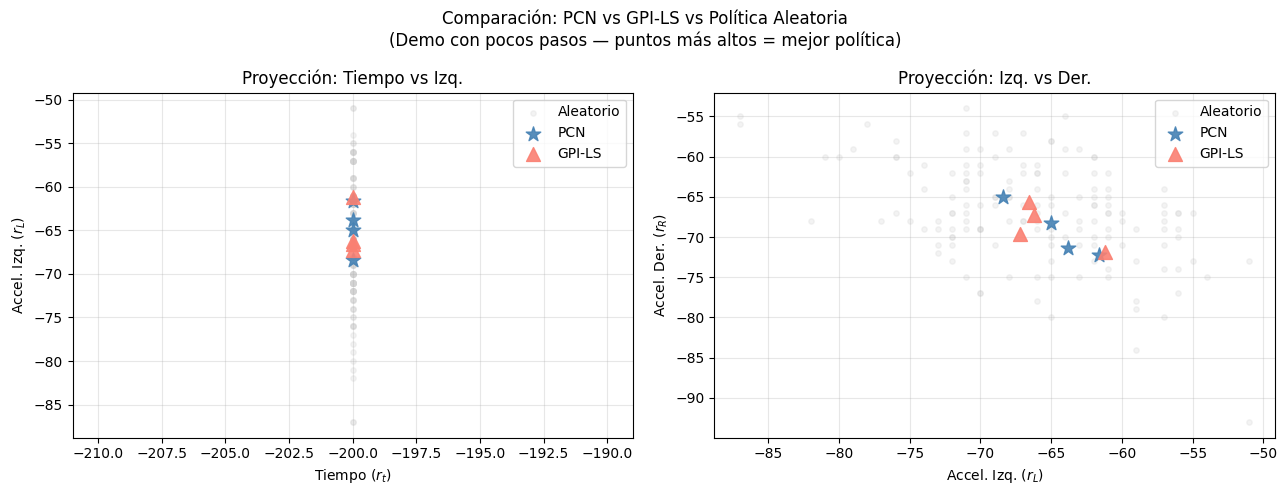


Resumen (media de evaluaciones):
  Algoritmo         r_t      r_L      r_R      Total
  --------------------------------------------------
  PCN            -200.0    -64.7    -69.2     -333.9
  GPI-LS         -200.0    -65.3    -68.6     -333.9
  Aleatorio      -200.0    -66.3    -66.9     -333.2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'Aleatorio': ('lightgray', 'o', 0.25, 15),
           'PCN': ('steelblue', '*', 0.9, 120),
           'GPI-LS': ('salmon', '^', 0.9, 100)}

for ax, (xi, yi, xlabel, ylabel, ptitle) in zip(axes, [
    (0, 1, 'Tiempo ($r_t$)', 'Accel. Izq. ($r_L$)', 'Tiempo vs Izq.'),
    (1, 2, 'Accel. Izq. ($r_L$)', 'Accel. Der. ($r_R$)', 'Izq. vs Der.'),
]):
    ax.scatter(samples[:,xi], samples[:,yi],
               c='lightgray', alpha=0.25, s=15, label='Aleatorio')
    if len(pcn_pts):
        ax.scatter(pcn_pts[:,xi], pcn_pts[:,yi],
                   c='steelblue', s=120, marker='*', alpha=0.9, zorder=5, label='PCN')
    if len(gpils_pts):
        ax.scatter(gpils_pts[:,xi], gpils_pts[:,yi],
                   c='salmon', s=100, marker='^', alpha=0.9, zorder=5, label='GPI-LS')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f'Proyección: {ptitle}')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Comparación: PCN vs GPI-LS vs Política Aleatoria\n'
             '(Demo con pocos pasos — puntos más altos = mejor política)', fontsize=12)
plt.tight_layout()
plt.savefig('videos/mc_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Resumen numérico
print('\nResumen (media de evaluaciones):')
print(f'  {"Algoritmo":<12} {"r_t":>8} {"r_L":>8} {"r_R":>8} {"Total":>10}')
print('  ' + '-' * 50)
for pts, name in [(pcn_pts, 'PCN'), (gpils_pts, 'GPI-LS')]:
    if len(pts):
        m = pts.mean(axis=0)
        print(f'  {name:<12} {m[0]:>8.1f} {m[1]:>8.1f} {m[2]:>8.1f} {m.sum():>10.1f}')
rnd_m = samples.mean(axis=0)
print(f'  {"Aleatorio":<12} {rnd_m[0]:>8.1f} {rnd_m[1]:>8.1f} {rnd_m[2]:>8.1f} {rnd_m.sum():>10.1f}')

## 10. Conclusiones

### Mountain Car Multiobjetivo — Lecciones Aprendidas

**1. Estado continuo invalida los métodos tabulares**
PQL y Q-Learning escalarizado tabular requieren un espacio de estados finito. Mountain Car tiene $\mathcal{S} \subset \mathbb{R}^2$, lo que exige redes neuronales para aproximar $Q(s, a; \theta)$.

**2. Los tres objetivos están en conflicto fundamental**
Para escapar el valle se *necesita* oscilación (acumular energía cinética), lo que inevitablemente acumula penalizaciones $r_L$ y $r_R$. El trade-off es real: no se puede minimizar todo simultáneamente.

**3. PCN: condicionamiento en retorno objetivo**
Una sola red parametriza todo el frente. Al cambiar $\mathbf{d}$ en `agent.eval(obs, d)` se obtiene una política diferente. La limitación: $\mathbf{d}$ son retornos absolutos, difíciles de especificar sin conocer el frente a priori.

**4. GPI-LS: pesos como preferencias intuitivas**
$\mathbf{w} = [w_t, w_L, w_R]$ expresa preferencias relativas — más intuitivo que retornos absolutos. Linear Support automatiza la selección eficiente de qué pesos explorar.

**5. 5000-10000 pasos no son suficientes para convergencia**
Estos son demos educativos. Para resultados de calidad:

| Algoritmo | Pasos para convergencia |
|---|---|
| PCN (Mountain Car) | ~500,000 |
| GPI-LS (Mountain Car) | ~200,000 |

### Referencias

- Reymond et al. (2022). *Pareto Conditioned Networks.* — PCN
- Alegre et al. (2023). *MORL-Baselines: Multi-Objective Reinforcement Learning Algorithms.* — GPI-LS/GPI-PD
- MO-Gymnasium: https://mo-gymnasium.farama.org/environments/mo-mountaincar